In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv('Placement_Data_Full_Class.csv')

In [82]:
dataset

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,211,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,212,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,213,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0
213,214,F,74.00,Others,66.00,Others,Commerce,58.00,Comm&Mgmt,No,70.0,Mkt&HR,60.23,Placed,204000.0


In [83]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

1) Replace the NaN values with correct value. And justify why you have
chosen the same


Solu : We replaced NaN values with 0 because Dataset shouldn't contains the NaN/Null Values 

Actually We have some Different Methods too 

i) Take the Central tendency

ii)Replacing the NaN/Null values with 0

iii)Create a machine learning model to predict the Salary which is not presented

iv) if there is more NaN/Null values presented we can delete the entire row

In [84]:
dataset['salary'].fillna(0,inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_2092\3738702580.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['salary'].fillna(0,inplace=True)


2) How many of them are not placed?


In [85]:
not_placed=(dataset['status']=="Not Placed").sum()
not_placed

np.int64(67)

3)Find the reason for non placement from the dataset?

4) What kind of relation between salary and mba_p

 5) Which specialization is getting minimum salary?

In [86]:
dataset[['specialisation']].min()

specialisation    Mkt&Fin
dtype: object

6) How many of them getting above 500000 salary?

In [87]:
salary=(dataset['salary']>500000).sum()

In [88]:
salary

np.int64(3)

7) Test the Analysis of Variance between etest_p and mba_p at signifance
level 5%.(Make decision using Hypothesis Testing)


In [90]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
etest_p=dataset['etest_p']
mba_p=dataset['mba_p']
ttest_ind(etest_p,mba_p)

TtestResult(statistic=np.float64(9.932012413063472), pvalue=np.float64(4.672547689134018e-21), df=np.float64(428.0))

8) Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary at significance level of 5%.(Make
decision using Hypothesis Testing)

In [19]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
sci=dataset[dataset['degree_t']=='Sci&Tech']['salary']
hr=dataset[dataset['degree_t']=="Mkt&HR"]['salary']
ttest_ind(sci,hr)

C:\Users\USER\anaconda3\envs\aiml\Lib\site-packages\scipy\_lib\deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

 9) Convert the normal distribution to standard normal distribution for
salary column

In [20]:
def stdNBgraph(dataset):
    #convert to standard Normal Distribution 

    import seaborn as sns 
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std)for j in values]

    sns.distplot(z_score,kde=True)
    sum(z_score)/len(z_score)

C:\Users\USER\AppData\Local\Temp\ipykernel_8328\770399935.py:12: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


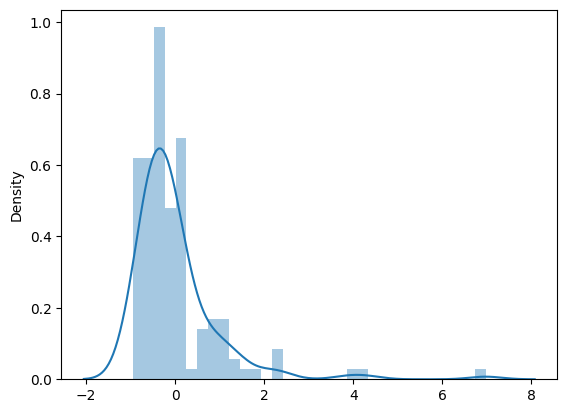

In [23]:
stdNBgraph(dataset['salary'])

10) What is the probability Density Function of the salary range from
700000 to 900000?


11) Test the similarity between the degree_t(Sci&Tech)with respect to
etest_p and mba_p at significance level of 5%.(Make decision using Hypothesis Testing)

In [32]:
from scipy.stats import ttest_ind
dataset.dropna()
degree_t=dataset[dataset['degree_t']=='Sci&Tech']
etest = degree_t["etest_p"]
mba = degree_t["mba_p"]
ttest_ind(etest, mba)

TtestResult(statistic=np.float64(4.286330847883898), pvalue=np.float64(5.027752902669624e-05), df=np.float64(80.0))

12) Which parameter is highly correlated with salary?

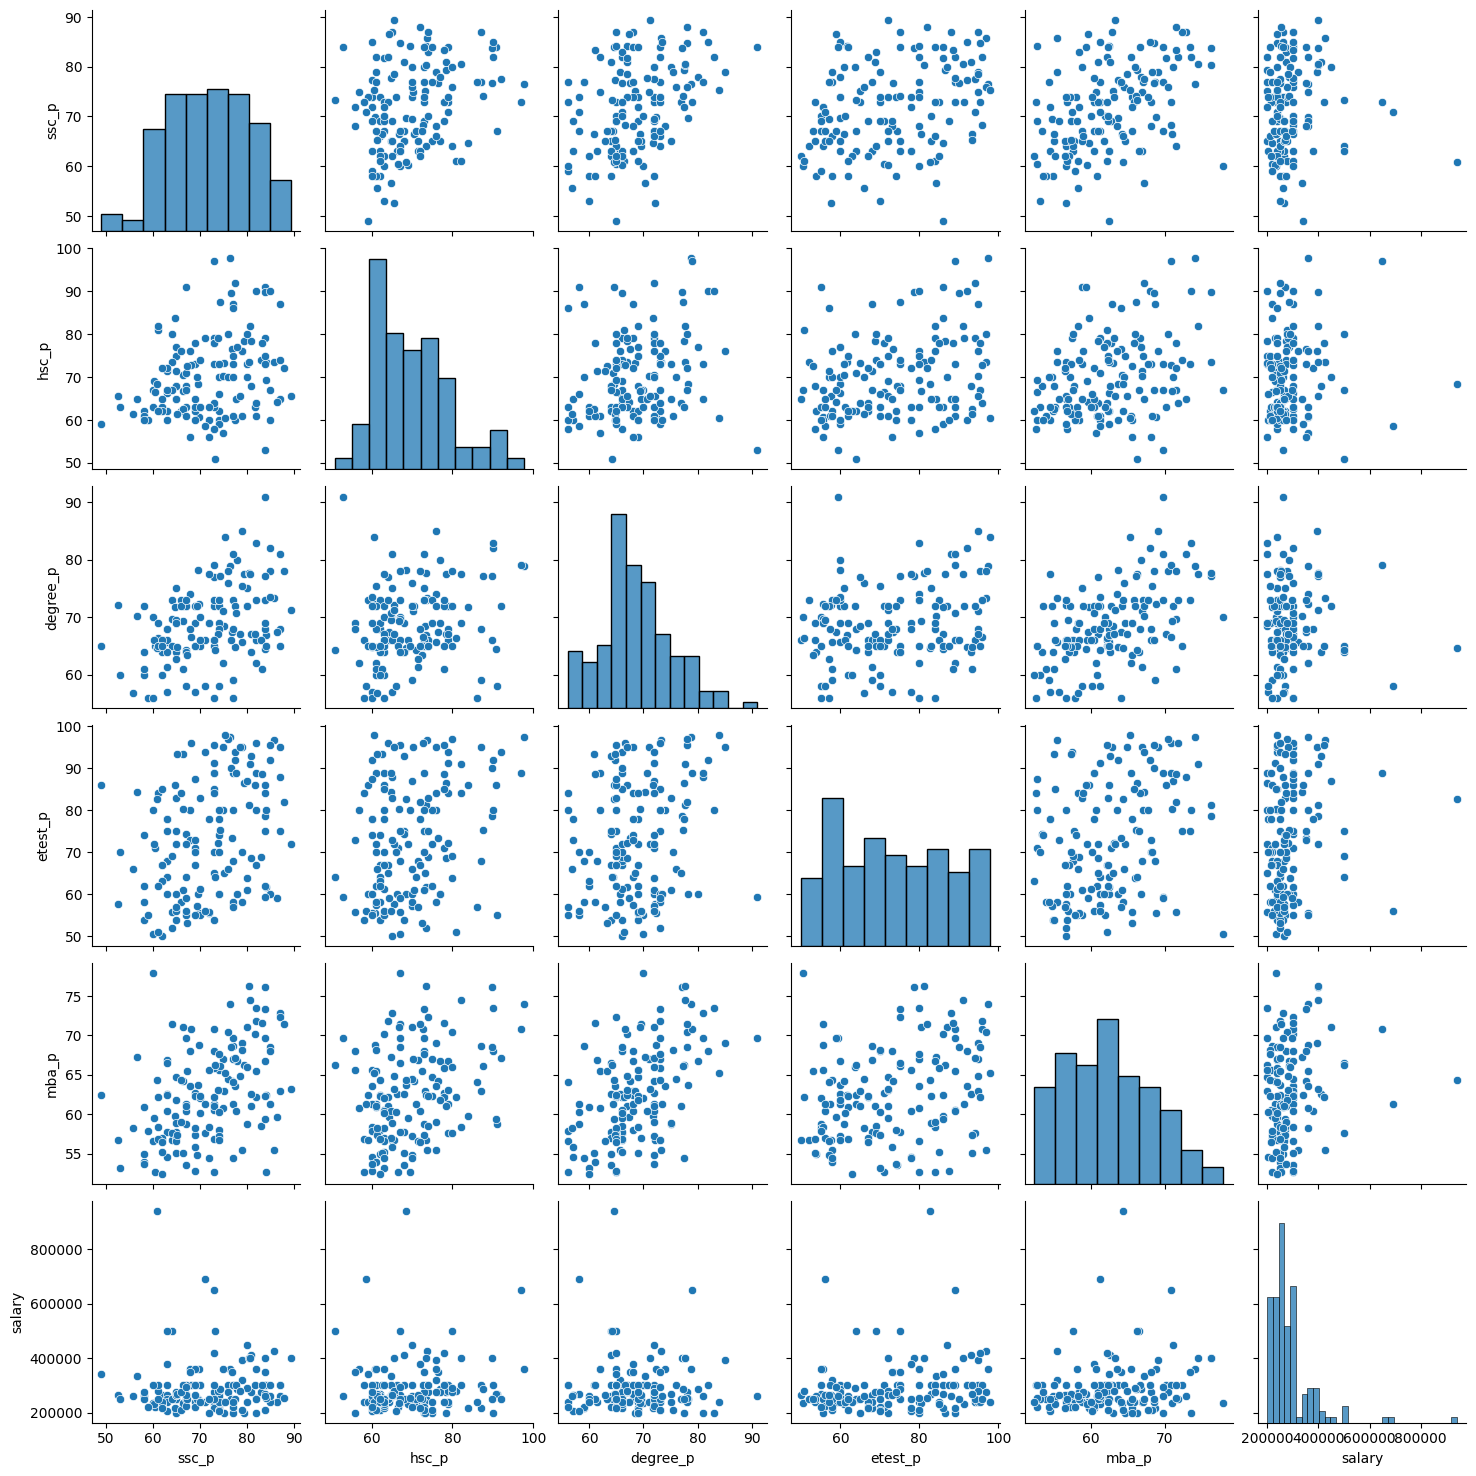

In [44]:
import seaborn as sns
sns.pairplot(dataset)
from statsmodels.stats.outliers_influence import variance_inflation_factor
def cal_vif(x):
    VIF=pd.DataFrame()
    VIF['Variables']=x.columns
    VIF['VIF']=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
    return VIF



In [46]:
#cal_vif(dataset[['salary']])

14) plot any useful graph and explain it.
